Data du rheometre de Y16SE4 a 1mM:
- 27/01/2025

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import os
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar, curve_fit, least_squares, leastsq
from scipy.special import gamma

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
π = np.pi
def fmmGp(ω, V, G, α, β):
    '''Elastic modulus of the Fractional Maxwell Model'''
    Go = G*ω**β
    Vo = V*ω**α
    return (
        Go**2 * Vo * np.cos(π*α/2) + Vo**2 * Go * np.cos(π*β/2)
    )/(
        Vo**2 + Go**2 + 2*Vo*Go*np.cos(π*(α-β)/2)
    )

def fmmGpp(ω, V, G, α, β):
    '''Viscous modulus of the Fractional Maxwell Model'''
    Go = G*ω**β
    Vo = V*ω**α
    return (
        Go**2 * Vo * np.sin(π*α/2) + Vo**2 * Go * np.sin(π*β/2)
    )/(
        Vo**2 + Go**2 + 2*Vo*Go*np.cos(π*(α-β)/2)
    )

def fmmtandelta(ω, V, G, α, β):
    '''Loss tangent of the Fractional Maxwell Model'''
    Go = G*ω**β
    Vo = V*ω**α
    return (
        Go * np.sin(π*α/2) + Vo * np.sin(π*β/2)
    )/(
        Go * np.cos(π*α/2) + Vo * np.cos(π*β/2)
    )

def mmtandelta(ω, k, τ):
    '''Loss tangent of the Maxwell Model'''
    return 1/(τ * ω)
def mmGp(ω, k, η):
    '''Elastic modulus of the Maxwell Model'''
    τ = η/k
    return k * (
        τ**2 * ω**2
    )/(
        1 + τ**2 * ω**2
    )
def mmGpp(ω, k, η):
    '''Viscous modulus of the Maxwell Model'''
    τ = η/k
    return k * (
        τ * ω
    )/(
        1 + τ**2 * ω**2
    )
def fit_fmm(omegas, Gp, Gpp, V0=1, G0=1, α0=1, β0=0):
    """Fit simultaneously G' and G'' to the Fractional Maxwell Model"""
    assert len(omegas) == len(Gp)
    assert len(omegas) == len(Gpp)
    return curve_fit(
        f=lambda ω, V, G, α, β: np.concatenate([np.log(fmmGp(ω, V, G, α, β)), np.log(fmmGpp(ω, V, G, α, β))]), 
        xdata=omegas, 
        ydata=np.concatenate([np.log(Gp), np.log(Gpp)]),
        p0=[V0, G0, α0, β0], 
        #sigma=res_phi/phi[m:M2]
        bounds=([0,0,0,0], [np.inf, np.inf, 1, 1])
    )

def fmmTau(V, G, α, β):
    '''Characteristic time of the Fractional Maxwell Model'''
    return (V/G * (np.cos(π*β/2) - np.sin(π*β/2)) / (np.sin(π*α/2) - np.cos(π*α/2)))**(1/(α-β))

def fmmVGratio(τ, α, β):
    '''Ratio between quasi-properties V / G, given characteristic time tau and exponents alpha and beta'''
    return (np.sin(π*α/2) - np.cos(π*α/2)) / (np.cos(π*β/2) - np.sin(π*β/2)) * τ**(α-β)

def fmmMSD(t, Dα, τ, α, β):
    '''Mean squarte displacement in the Fractional Maxwell Model'''
    return 2*Dα * (τ**(α-β) * t**β/gamma(1+β) + t**α/gamma(1+α))

def fmmGppT(p, ωs, Gps, Gpps):
    α, β = p[:2]
    Vs = p[2:2+len(ωs)]
    Gs = p[2+len(ωs):2+2*len(ωs)]
    out = []
    for V, G, ω, Gp, Gpp in zip(Vs, Gs, ωs, Gps, Gpps):
        out.append(np.log(fmmGp(ω, V, G, α, β)) - np.log(Gp))
        out.append(np.log(fmmGpp(ω, V, G, α, β)) - np.log(Gpp))
    return np.concatenate(out)

# sample 27/01/2025

In [2]:
def get_moduli(file):
    filename = f'Y4-FS-{file}.tsv'
    data = np.loadtxt(filename, skiprows=2, delimiter='\t')
    Temp = data[0,6]
    freq, Gp, Gpp, tandelta = np.transpose(data[:,2:6])
    torque = np.transpose(data[:,7])
    mask = (Gp != 0) & (Gpp != 0)
    freq, Gp, Gpp, tandelta, torque = freq[mask], Gp[mask], Gpp[mask], tandelta[mask], torque[mask]
    return Temp, freq, Gp, Gpp, tandelta, torque    

def plot_moduli(n, ax, f_get_moduli=get_moduli, colors=colors):
    c = 0
    lines = []
    for i in n:
        T, freq, Gp, Gpp, tandelta, torque = f_get_moduli(i)
        torque *= 1e3
        line, = ax.plot(freq, Gp, marker='s', color=colors[c], linestyle='-', label=T)
        ax.errorbar(freq, Gpp, yerr=0.1/torque*Gpp, marker='v', color=line.get_color(), linestyle='-')
        lines.append(line)
        c += 1
    return lines

Text(0.5, 1.0, 'after annealing 90C, wait 5min')

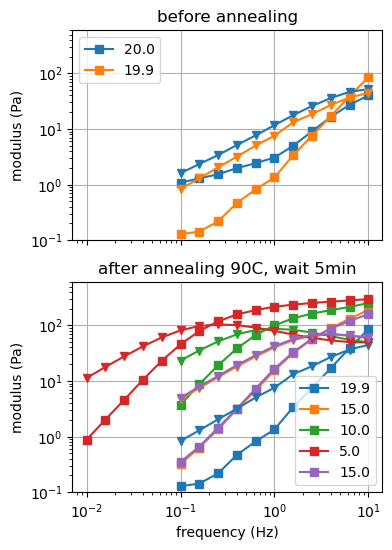

In [3]:
os.chdir(r"C:\Users\ajiye\Documents\Rheometre\20250127")

fig1, ax1 = plt.subplots(2,1, figsize=(4,6), sharex=True)

n = [1,2]
plot_moduli(n, ax1[0])

n = [3,4,5,6,7]
plot_moduli(n, ax1[1])

for ax in ax1:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel('modulus (Pa)')
    ax.legend()
    ax.grid()
    ax.set_ylim(0.1,6e2)
ax1[1].set_xlabel('frequency (Hz)')
ax1[0].set_title('before annealing')
ax1[1].set_title('after annealing 90C, wait 5min')

In [4]:
def plot_TTS_indivFMM(n, ax, f_get_moduli=get_moduli):
    c = 0
    params = []
    errors = []
    for i in n:
        T, freq, Gp, Gpp, tandelta, torque = f_get_moduli(i)
        freq *= 2*π
        torque *= 1e3
        line = axs[0,0].errorbar(freq, tandelta, 0.2/torque*tandelta, fmt='s', color=colors[c%12])[0]
        axs[1,0].errorbar(freq, Gp, 0.1/torque*Gp, fmt='o', color=line.get_color())
        axs[2,0].errorbar(freq, Gpp, 0.1/torque*Gpp, fmt='^', color=line.get_color(), label = f'T={T}')
        
        result = fit_fmm(freq, Gp, Gpp, 20, 5, 1, 0)
        V, G, alpha, beta = result[0]
        cov_V, cov_G, cov_alpha, cov_beta = result[1]
        if alpha < beta:
            alpha, beta = beta, alpha
            cov_alpha, cov_beta = cov_beta, cov_alpha
            V,G = G,V
            cov_V,cov_G = cov_G,cov_V
        err_V, err_G, err_alpha, err_beta = np.diag([cov_V, cov_G, cov_alpha, cov_beta])
        params.append([T, V, G, alpha, beta])
        errors.append([err_V, err_G, err_alpha, err_beta])
        print(f'T={T}\tα={alpha:0.3f}\tβ={beta:0.3f}\tV={V:0.3f}\tG={G:g}')
        if V<0 or G<0:
            print(f'Negative V={V} or G={G}, skipping data {i} at T={T}')
            continue
        tau = fmmTau(V, G, alpha, beta)
        #fits
        axs[0,0].plot(freq, fmmtandelta(freq, V, G, alpha, beta), '-', color=line.get_color())
        axs[1,0].plot(freq, fmmGp(freq, V, G, alpha, beta), '-', color=line.get_color(), label=f'$\alpha={alpha:0.3f}, \beta={beta:0.3f}$')
        axs[2,0].plot(freq, fmmGpp(freq, V, G, alpha, beta), '-', color=line.get_color())
        
        #collapse
        axs[0,1].errorbar(freq * tau, tandelta, 0.2/torque*tandelta, fmt='s', label = f'T={T}', color=line.get_color())
        fit_tandelta = fmmtandelta(freq * tau, V=1, G=1, α=alpha, β=beta)
        #axs[0,1].plot(freq * tau, fit_tandelta, '--', color=line.get_color())
        axs[1,1].errorbar(freq * tau, Gp/G*tau**beta, 0.1/torque*Gp/G*tau**beta, fmt='o', color=line.get_color())
        axs[2,1].errorbar(freq * tau, Gpp/G*tau**beta, 0.1/torque*Gpp/G*tau**beta, fmt='^', color=line.get_color())
        print(tau, beta)
        c += 1

def plot_TTS_global(n, axs, f_get_moduli=get_moduli):
    Ts, freqs, Gps, Gpps, tandeltas = [], [], [], [], []
    for i in n:
        T, freq, Gp, Gpp, tandelta, torque = f_get_moduli(i)
        Ts.append(T)
        freqs.append(freq*2*np.pi)
        Gps.append(Gp)
        Gpps.append(Gpp)
        tandeltas.append(tandelta)
    
    params = leastsq(
        fmmGppT,
        [1,0] + len(n)*[1,1],
        args = ([freq for freq in freqs],
            [Gp for Gp in Gps],
            [Gpp for Gpp in Gpps],)
    )[0]
    if params[0]<params[1]:
        params = np.concatenate(([params[1], params[0]], params[2+len(n):], params[2:2+len(n)]))

    for i in range(len(n)):
        V = params[2+i]
        G = params[2+len(freqs)+i]
        if V>0 and G>0:
            continue
        print(i)
        freq, Gp, Gpp = freqs[i], Gps[i], Gpps[i]
        #m = np.argmax(Gpp/Gp)
        V,G = curve_fit(
            f=lambda ω, V, G: np.concatenate([np.log(fmmGp(ω, V, G, params[0], params[1])), np.log(fmmGpp(ω, V, G, params[0], params[1]))]), 
            xdata=freq, 
            ydata=np.concatenate([np.log(Gp), np.log(Gpp)]),
            p0=[1, 1], 
            bounds=([0,0],[np.inf, np.inf]),
            sigma=np.concatenate([1/torque]*2)
        )[0]
        params[2+i] = V
        params[2+len(n)+i] = G

    alpha, beta = params[:2]
    print(f'alpha = {alpha:.2f}, beta = {beta:.2f}')
    c = 0
    
    for i in range(len(n)):
        T = Ts[i]
        V = params[2+i]
        G = params[2+len(n)+i]
        if V<0 or G<0:
            print(f'Negative V={V} or G={G}, skipping data {i} at T={T}')
            continue
        tau = fmmTau(V, G, alpha, beta)
        freq, Gp, Gpp, tandelta = freqs[i], Gps[i], Gpps[i], tandeltas[i]
        freq *= tau
        line, = axs[0].plot(freq, tandelta, 's', color=colors[c%12], label = f'T={T}')
        axs[1].plot(freq, Gp, 'o', color=line.get_color())
        axs[1].plot(freq, Gpp, '^', color=line.get_color())
        c += 1

T=19.9	α=0.955	β=0.000	V=1.637	G=84.8672
0.01733109108403983 1.6804552940910695e-19
T=15.0	α=0.983	β=0.034	V=7.939	G=140.865
0.04681543561567811 0.03414677266521484
T=10.0	α=1.000	β=0.089	V=39.253	G=153.808
0.1866985067844991 0.08946487579745034
T=5.0	α=0.996	β=0.091	V=182.867	G=204.443
0.7412526952405722 0.0907943326192707
T=15.0	α=0.985	β=0.053	V=8.195	G=130.091
0.04804117945262544 0.05259918098196077
alpha = 0.98, beta = 0.07


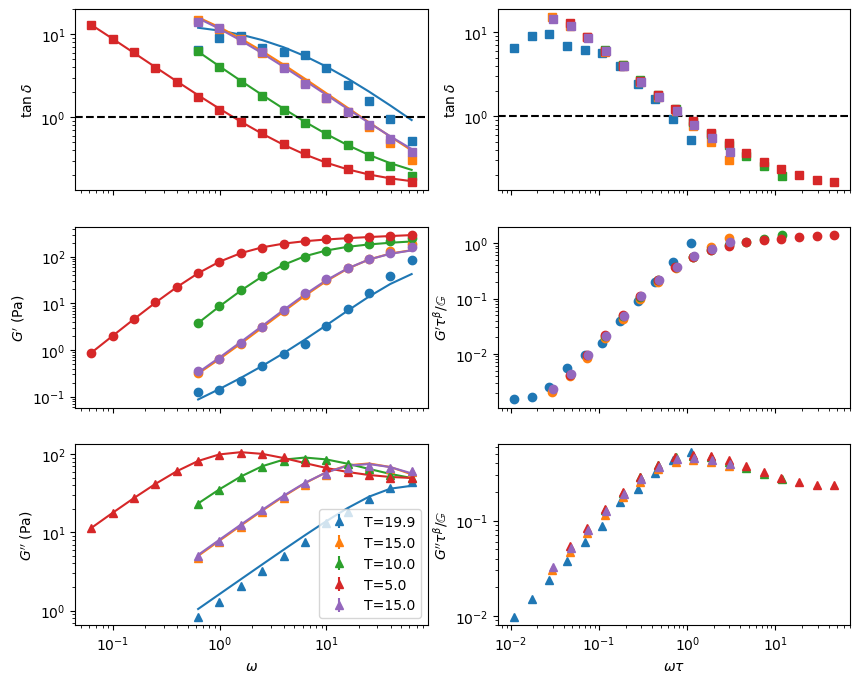

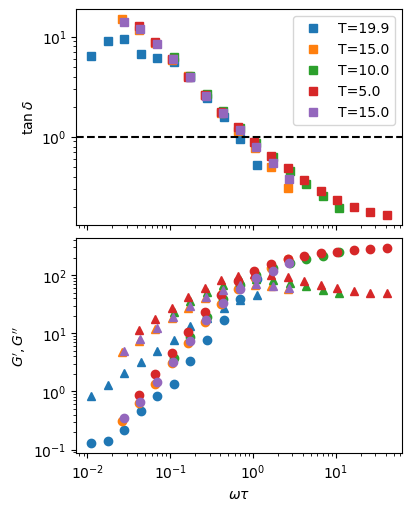

In [5]:
fig, axs = plt.subplots(3,2, sharex='col', figsize=(10,8))

n = [3,4,5,6,7]
plot_TTS_indivFMM(n, axs, get_moduli)
for ax in axs.ravel():
    ax.set_yscale('log')
    ax.set_xscale('log')

axs[2,0].set_xlabel(r'$\omega$')
axs[0,0].set_ylabel(r'$\tan\delta$')
axs[1,0].set_ylabel(r'$G^\prime$ (Pa)')
axs[2,0].set_ylabel(r'$G^{\prime\prime}$ (Pa)')

axs[2,1].set_xlabel(r'$\omega\tau$')
axs[0,1].set_ylabel(r'$\tan\delta$')
axs[1,1].set_ylabel(r'$G^\prime\tau^{\beta}/\mathbb{G}$')
axs[2,1].set_ylabel(r'$G^{\prime\prime}\tau^{\beta}/\mathbb{G}$')
axs[2,0].legend()
for ax in axs[0]:
    ax.axhline(1,ls='--', color='k')

fig2, axs2 = plt.subplots(2,1, sharex=True, layout="constrained", figsize=(4,5))

n = [3,4,5,6,7]
plot_TTS_global(n, axs2, get_moduli)

plt.xscale('log')
axs2[0].set_yscale('log')
axs2[1].set_yscale('log')
axs2[1].set_xlabel(r'$\omega\tau$')
axs2[0].set_ylabel(r'$\tan\delta$')
axs2[1].set_ylabel(r'$G^\prime, G^{\prime\prime}$')
axs2[0].legend()
axs2[0].axhline(1,ls='--', color='k')

Text(0.5, 1.0, 'control curves')

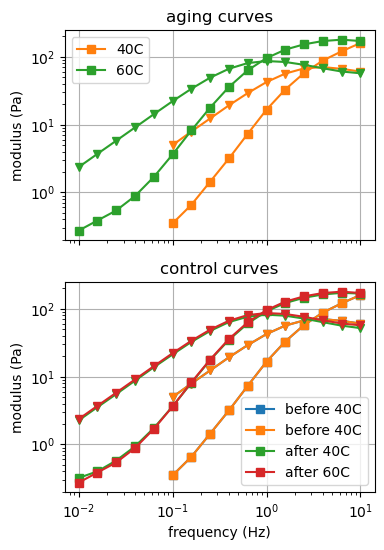

In [7]:
# aging test
fig2, ax2 = plt.subplots(2,1, figsize=(4,6), sharex=True)

n = [9,11]
lines1 = plot_moduli2(n, ax2[0], colors[1:])
labels1 = ['40C', '60C']

n = [7,8,10,12]
lines2 = plot_moduli2(n, ax2[1])
labels2 = ['before 40C', 'before 40C', 'after 40C', 'after 60C']

for ax in ax2:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel('modulus (Pa)')
    ax.grid()
    # ax.set_ylim(1,2e3)
ax2[1].set_xlabel('frequency (Hz)')
ax2[0].legend(lines1, labels1)
ax2[1].legend(lines2, labels2)
ax2[0].set_title('aging curves')
ax2[1].set_title('control curves')

<>:14: SyntaxWarning: invalid escape sequence '\%'
<>:14: SyntaxWarning: invalid escape sequence '\%'
C:\Users\ajiye\AppData\Local\Temp\ipykernel_76380\2312214172.py:14: SyntaxWarning: invalid escape sequence '\%'
  line, = ax.plot(time, tau, marker='o', color=colors[c%len(n)], linestyle='-', label=f'{gamma[0]}$\%$')


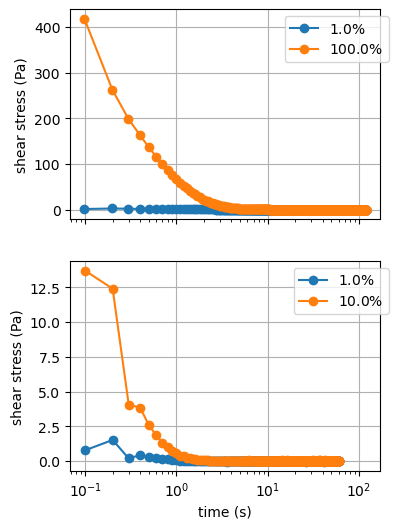

In [13]:
def get_strain(file):
    filename = f'Y4-strain-{file}.tsv'
    data = np.genfromtxt(filename, skip_header=2, delimiter='\t', usecols=(0,6,7,8), dtype=float)
    Temp = data[0,1]
    time = data[:,0]
    gamma, tau = np.transpose(data[:,2:])
    return Temp, time, gamma, tau

def plot_strain(n, ax):
    c = 0
    lines = []
    for i in n:
        T, time, gamma, tau = get_strain(i)
        line, = ax.plot(time, tau, marker='o', color=colors[c%len(n)], linestyle='-', label=f'{gamma[0]}$\%$')
        lines.append(line)
        c += 1
    return lines

fig2, ax2 = plt.subplots(2,1, figsize=(4,6), sharex=True)

n = [1,5]
plot_strain(n, ax2[0])

n = [7,9]
plot_strain(n, ax2[1])

ax2[1].set_xscale('log')
ax2[1].set_xlabel('time (s)')
for ax in ax2:
    ax.set_ylabel('shear stress (Pa)')
    ax.grid()
    ax.legend(bbox_to_anchor=(1.05,1))